# Identifying Heart Disease in Patients Using Machine Learning Project

---

### Project Information
* **Course:** ENBC321 – Machine Learning for Data Analysis
* **Instructor:** Professor Jimmy Azarnoosh
* **Date:** March 13, 2026

---

### Team Members
* **Avneet Bahra**
* **Arinze Ezeifeka**
* **Christopher Nolan Lee**
* **Joel Thomas**

---

## Executive Summary
The topic of our project is predicting the presence of heart disease in patients using clinical and demographic data. The key issue we plan to address is identifying which specific health factors—such as age, cholesterol levels, maximum heart rate, and chest pain type—are the strongest predictors of heart disease. By understanding these relationships, the aim of this project is to suggest which clinical indicators most significantly promote a higher risk of heart disease. Our hypothesis statement is that patients exhibiting a combination of exercise-induced angina, specific chest pain types, and elevated resting blood pressure will have a significantly higher probability of heart disease compared to others. To justify this hypothesis, we will analyze the Heart Disease Dataset from Kaggle, which includes 14 key variables such as age, sex, chest pain type (cp), serum cholesterol (chol), maximum heart rate achieved (thalach), and a target variable indicating the presence (1) or absence (0) of the disease. Specifically, this study aims to use machine learning techniques to discover the correlative relationships between these cardiovascular metrics and positive diagnoses. Currently, our main concern regarding the project is that the dataset originates from 1988; this older time stamp could mean that the population baselines or diagnostic thresholds may differ slightly from modern medical standards, potentially making the model's assertions less relevant to present-day patients.

---

## Datasets
1. Lapp, D. (2019, June 6). Heart disease dataset. Kaggle. https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
2. Zaki, A. M. (2026, January 15). Cardiovascular disease risk assessment dataset. Kaggle. https://www.kaggle.com/datasets/ahmeduzaki/cardiovascular-disease-risk-assessment-dataset

# Libraries & Data Import
---

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import sklearn
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE, SequentialFeatureSelector as SFSskl, SelectKBest, f_regression, mutual_info_regression
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

!pip install catboost

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)


from mlxtend.feature_selection import SequentialFeatureSelector as SFSmlx

import warnings
warnings.filterwarnings("ignore")


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



## Cell 1: Import Libraries

This cell imports the main libraries used for data cleaning, model training, evaluation, visualization, and SHAP interpretation.


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier

from sklearn.feature_selection import (
    RFE,
    SequentialFeatureSelector,
    SelectKBest,
    f_regression,
    mutual_info_regression
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    r2_score,
    mean_squared_error
)

from sklearn.inspection import permutation_importance
import statsmodels.api as sm

## Cell 2: Load Datasets

This cell loads the original heart disease dataset and the second cardiovascular disease risk dataset.
"""

In [ ]:
HEART_PATH = '/content/drive/MyDrive/Colab Notebooks/ENBC 321/ML Project/heart.csv'
CVD_PATH = '/content/drive/MyDrive/Colab Notebooks/ENBC 321/ML Project/CVD Dataset.csv'

df1 = pd.read_csv(HEART_PATH)
df2 = pd.read_csv(CVD_PATH)

print("Dataset 1: Heart Disease Dataset")
display(df1.head())
print(df1.info())
print(df1["target"].value_counts())

print("\nDataset 2: CVD Risk Dataset")
display(df2.head())
print(df2.info())
print(df2["CVD Risk Level"].value_counts())

Dataset 1: Heart Disease Dataset


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
target
1    526
0    499
Name: count, dtype: int64

Dataset 2: CVD Risk Dataset


,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,F,32.0,69.1,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,Low,N,171.0,0.504,125.0,79.0,Elevated,140.0,17.93,INTERMEDIARY
1,F,55.0,118.7,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,High,Y,169.0,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51,HIGH
2,M,NaN,NaN,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,High,Y,183.0,0.583,104.0,77.0,Normal,0.0,12.64,INTERMEDIARY
3,M,44.0,108.3,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,High,Y,NaN,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36,INTERMEDIARY
4,F,32.0,99.5,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,High,N,186.0,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88,INTERMEDIARY


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   object 
 1   Age                           1451 non-null   float64
 2   Weight (kg)                   1448 non-null   float64
 3   Height (m)                    1462 non-null   float64
 4   BMI                           1465 non-null   float64
 5   Abdominal Circumference (cm)  1462 non-null   float64
 6   Blood Pressure (mmHg)         1529 non-null   object 
 7   Total Cholesterol (mg/dL)     1456 non-null   float64
 8   HDL (mg/dL)                   1449 non-null   float64
 9   Fasting Blood Sugar (mg/dL)   1462 non-null   float64
 10  Smoking Status                1529 non-null   object 
 11  Diabetes Status               1529 non-null   object 
 12  Physical Activity Level       1529 non-null   object 
 13  Fam

## Cell 3: Dataset 1 Setup

Dataset 1 uses all 13 clinical features to predict whether a patient has heart disease.

Target:

- 0 = No heart disease
- 1 = Heart disease


In [ ]:

X1 = df1[
    [
        "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
        "thalach", "exang", "oldpeak", "slope", "ca", "thal"
    ]
].copy()

y1 = df1["target"].copy()

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=321,
    stratify=y1
)

print("Dataset 1 training shape:", X1_train.shape)
print("Dataset 1 testing shape:", X1_test.shape)

Dataset 1 training shape: (820, 13)
Dataset 1 testing shape: (205, 13)


## Cell 4: Dataset 1 Correlation Heatmap

This heatmap shows correlations between the Dataset 1 features and the heart disease target.


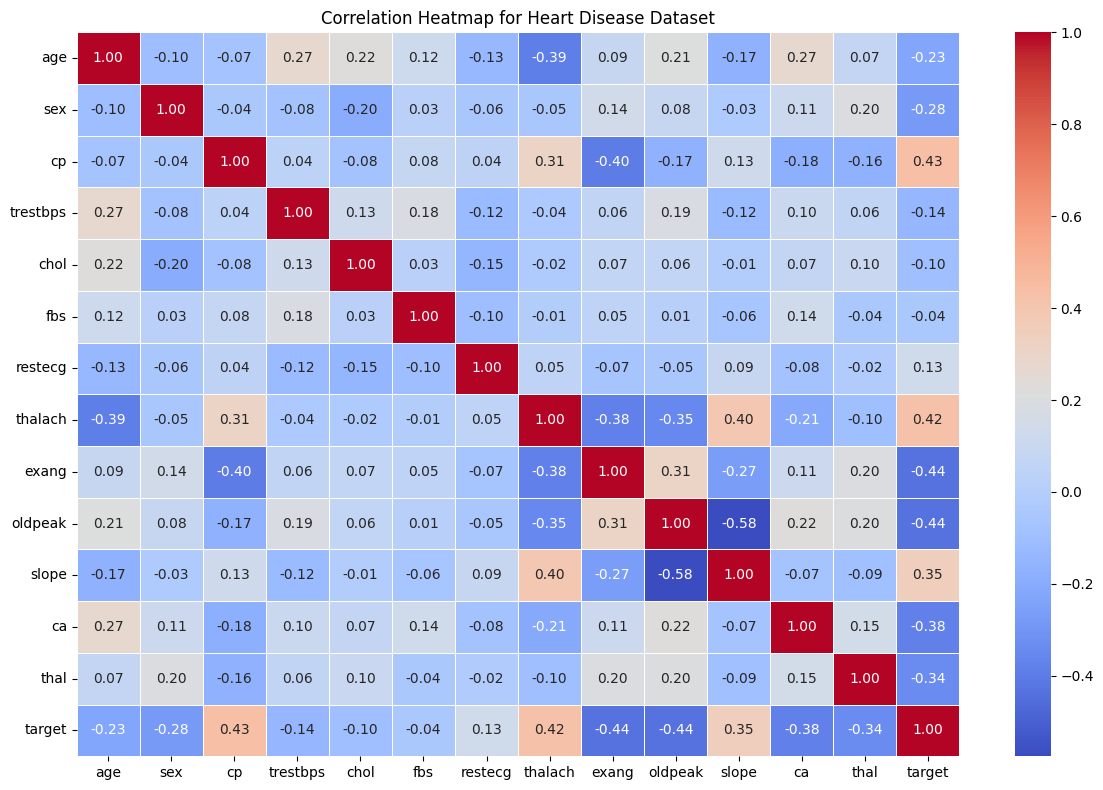

In [ ]:

plt.figure(figsize=(12, 8))
corr1 = df1.corr(numeric_only=True)

sns.heatmap(
    corr1,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap for Heart Disease Dataset")
plt.tight_layout()
plt.show()


## Cell 5: Define Classification Models

The same set of classification models is used for both datasets:

1. Logistic Regression
2. SVM
3. KNN
4. Decision Tree
5. Random Forest
6. Gradient Boosting


In [ ]:

models1 = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=321))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=321))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=321,
        max_depth=4
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=321,
        max_depth=5
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=321
    )
}


## Cell 6: Dataset 1 Model Metrics Table

This cell trains every model on Dataset 1 and prints a comparison table using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC


In [ ]:

results1 = []

for name, model in models1.items():
    model.fit(X1_train, y1_train)

    y1_pred = model.predict(X1_test)

    if hasattr(model, "predict_proba"):
        y1_prob = model.predict_proba(X1_test)[:, 1]
    else:
        y1_prob = model.decision_function(X1_test)

    results1.append({
        "Model": name,
        "Accuracy": accuracy_score(y1_test, y1_pred),
        "Precision": precision_score(y1_test, y1_pred),
        "Recall": recall_score(y1_test, y1_pred),
        "F1 Score": f1_score(y1_test, y1_pred),
        "ROC-AUC": roc_auc_score(y1_test, y1_prob)
    })

results1_df = pd.DataFrame(results1).sort_values(by="ROC-AUC", ascending=False)
display(results1_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
5,Gradient Boosting,0.941463,0.926606,0.961905,0.943925,0.992667
4,Random Forest,0.921951,0.908257,0.942857,0.925234,0.973714
1,SVM,0.873171,0.883495,0.866667,0.875000,0.959143
3,Decision Tree,0.858537,0.904255,0.809524,0.854271,0.940000
2,KNN,0.785366,0.790476,0.790476,0.790476,0.933619
0,Logistic Regression,0.824390,0.794872,0.885714,0.837838,0.883333


## Cell 7: Dataset 1 Confusion Matrices and Classification Reports

This cell prints a confusion matrix and classification report for every Dataset 1 model.


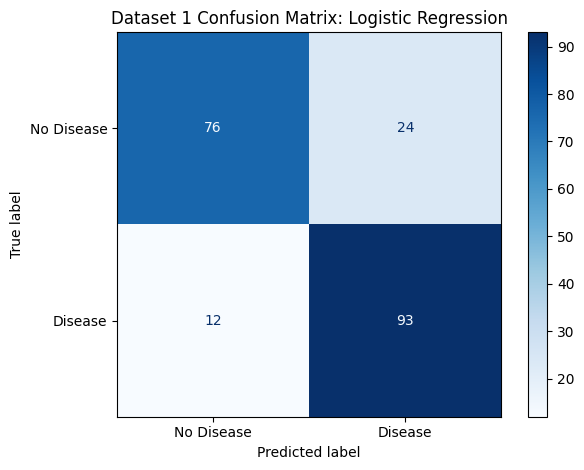


Logistic Regression
              precision    recall  f1-score   support

  No Disease       0.86      0.76      0.81       100
     Disease       0.79      0.89      0.84       105

    accuracy                           0.82       205
   macro avg       0.83      0.82      0.82       205
weighted avg       0.83      0.82      0.82       205



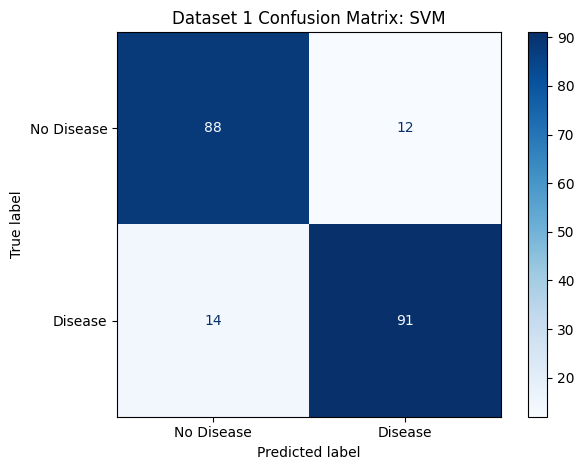


SVM
              precision    recall  f1-score   support

  No Disease       0.86      0.88      0.87       100
     Disease       0.88      0.87      0.88       105

    accuracy                           0.87       205
   macro avg       0.87      0.87      0.87       205
weighted avg       0.87      0.87      0.87       205



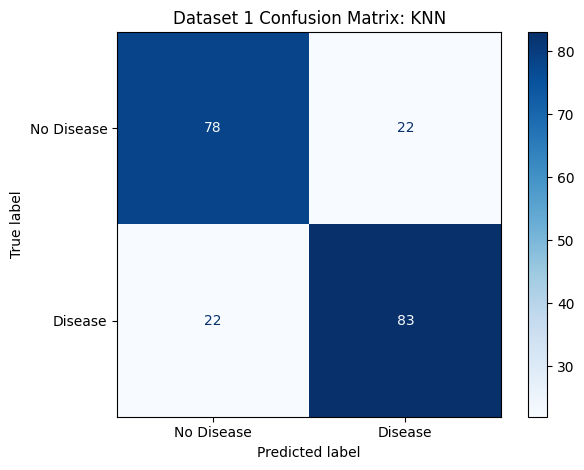


KNN
              precision    recall  f1-score   support

  No Disease       0.78      0.78      0.78       100
     Disease       0.79      0.79      0.79       105

    accuracy                           0.79       205
   macro avg       0.79      0.79      0.79       205
weighted avg       0.79      0.79      0.79       205



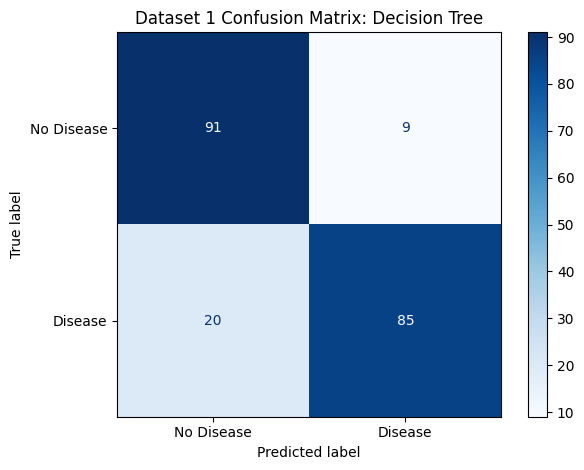


Decision Tree
              precision    recall  f1-score   support

  No Disease       0.82      0.91      0.86       100
     Disease       0.90      0.81      0.85       105

    accuracy                           0.86       205
   macro avg       0.86      0.86      0.86       205
weighted avg       0.86      0.86      0.86       205



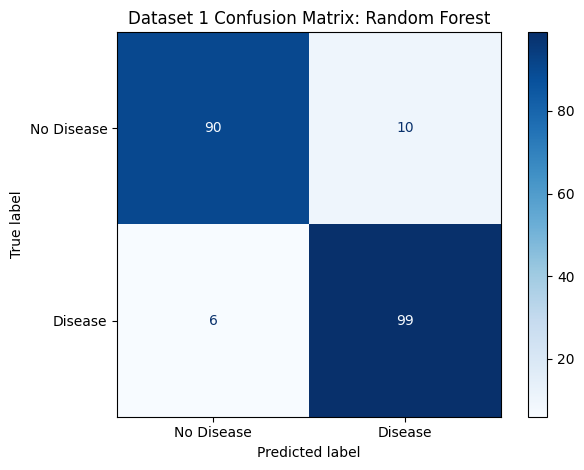


Random Forest
              precision    recall  f1-score   support

  No Disease       0.94      0.90      0.92       100
     Disease       0.91      0.94      0.93       105

    accuracy                           0.92       205
   macro avg       0.92      0.92      0.92       205
weighted avg       0.92      0.92      0.92       205



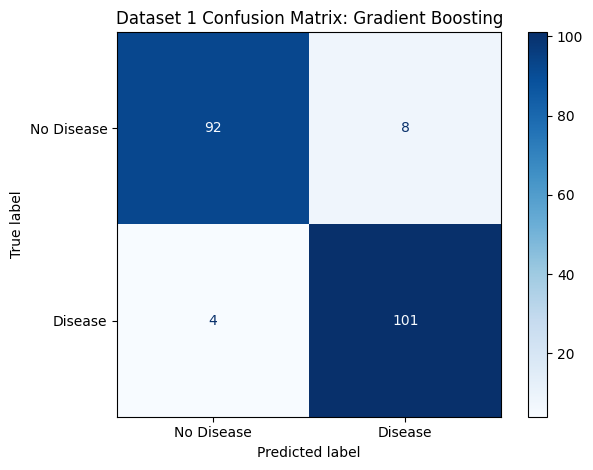


Gradient Boosting
              precision    recall  f1-score   support

  No Disease       0.96      0.92      0.94       100
     Disease       0.93      0.96      0.94       105

    accuracy                           0.94       205
   macro avg       0.94      0.94      0.94       205
weighted avg       0.94      0.94      0.94       205



In [ ]:
for name, model in models1.items():
    y1_pred = model.predict(X1_test)

    cm = confusion_matrix(y1_test, y1_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Disease", "Disease"]
    )

    disp.plot(cmap="Blues")
    plt.title(f"Dataset 1 Confusion Matrix: {name}")
    plt.tight_layout()
    plt.show()

    print(f"\n{name}")
    print(classification_report(
        y1_test,
        y1_pred,
        target_names=["No Disease", "Disease"]
    ))


## Cell 8: Dataset 1 SHAP Summary Plot

SHAP explains how each feature contributes to the Gradient Boosting model's predictions.

For Dataset 1, Gradient Boosting performed very well, so it is used for SHAP interpretation.
"""

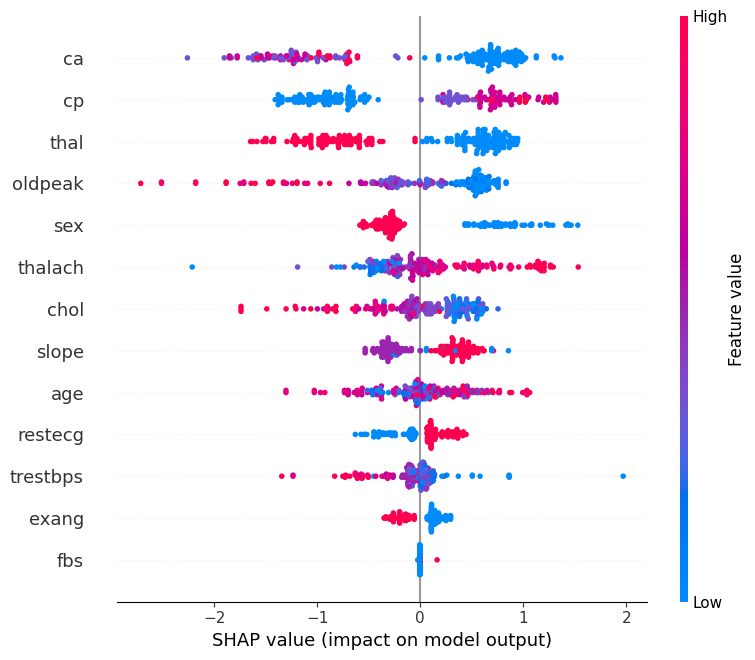

In [ ]:

!pip install shap -q

import shap

gb1 = GradientBoostingClassifier(random_state=321)
gb1.fit(X1_train, y1_train)

explainer1 = shap.Explainer(gb1, X1_train)
shap_values1 = explainer1(X1_test)

shap.summary_plot(shap_values1, X1_test)

## Cell 9: Dataset 1 ROC Curves With Confidence Bands

This cell plots ROC curves for every Dataset 1 model with bootstrap confidence bands.


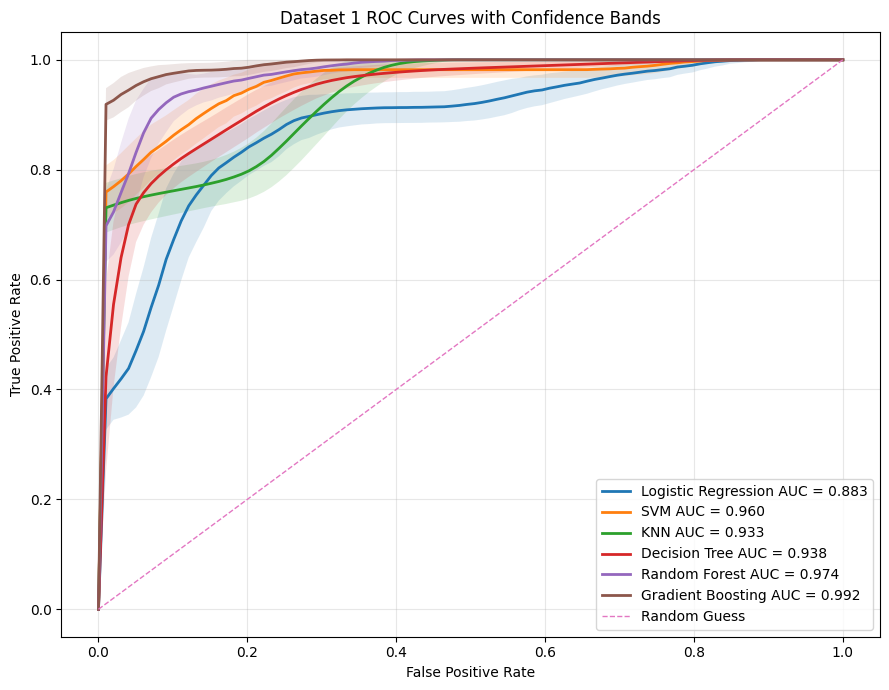

In [ ]:

plt.figure(figsize=(9, 7))

n_bootstraps = 300
rng = np.random.RandomState(321)
mean_fpr = np.linspace(0, 1, 100)

for name, model in models1.items():
    model.fit(X1_train, y1_train)

    if hasattr(model, "predict_proba"):
        y1_score = model.predict_proba(X1_test)[:, 1]
    else:
        y1_score = model.decision_function(X1_test)

    y1_test_array = np.array(y1_test)
    y1_score_array = np.array(y1_score)

    tprs = []
    aucs = []

    for i in range(n_bootstraps):
        indices = rng.randint(0, len(y1_score_array), len(y1_score_array))

        if len(np.unique(y1_test_array[indices])) < 2:
            continue

        fpr_boot, tpr_boot, _ = roc_curve(
            y1_test_array[indices],
            y1_score_array[indices]
        )

        aucs.append(auc(fpr_boot, tpr_boot))

        interp_tpr = np.interp(mean_fpr, fpr_boot, tpr_boot)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)

    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)

    tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
    tpr_lower = np.maximum(mean_tpr - std_tpr, 0)

    plt.plot(
        mean_fpr,
        mean_tpr,
        linewidth=2,
        label=f"{name} AUC = {np.mean(aucs):.3f}"
    )

    plt.fill_between(
        mean_fpr,
        tpr_lower,
        tpr_upper,
        alpha=0.15
    )

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Dataset 1 ROC Curves with Confidence Bands")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Dataset 2 Analysis Using Only the 5 Selected Features

The original Dataset 2 model used many encoded features. This revised version only uses the 5 selected features from the feature-selection analysis:

1. Weight (kg)
2. BMI
3. Total Cholesterol (mg/dL)
4. Systolic BP
5. Diabetes Status_Y

The target is CVD Risk Level:

- HIGH
- INTERMEDIARY
- LOW



## Cell 10: Dataset 2 Preprocessing With Only 5 Selected Features

This cell prepares Dataset 2 for multiclass classification and restricts the model input to only the 5 selected features.


In [ ]:
df2_model = df2.copy()

# Keep the target
target2 = "CVD Risk Level"

# Fill missing values before encoding
for col in df2_model.columns:
    if df2_model[col].dtype == "object":
        df2_model[col] = df2_model[col].fillna(df2_model[col].mode()[0])
    else:
        df2_model[col] = df2_model[col].fillna(df2_model[col].median())

# Separate raw X and y
X2_raw = df2_model.drop(columns=[target2])
y2_raw = df2_model[target2]

# One-hot encode categorical variables
X2_encoded = pd.get_dummies(X2_raw, drop_first=True)

# Selected 5 features from feature-selection analysis
selected_features2 = [
    "Weight (kg)",
    "BMI",
    "Total Cholesterol (mg/dL)",
    "Systolic BP",
    "Diabetes Status_Y"
]

# Restrict Dataset 2 to only the selected 5 features
X2 = X2_encoded[selected_features2].copy()

# Encode target labels
le2 = LabelEncoder()
y2 = le2.fit_transform(y2_raw)

print("Dataset 2 selected features:")
print(selected_features2)

print("\nTarget classes:")
print(list(le2.classes_))

print("\nEncoded target counts:")
print(pd.Series(y2).value_counts().sort_index())

display(X2.head())

Dataset 2 selected features:
['Weight (kg)', 'BMI', 'Total Cholesterol (mg/dL)', 'Systolic BP', 'Diabetes Status_Y']

Target classes:
['HIGH', 'INTERMEDIARY', 'LOW']

Encoded target counts:
0    728
1    581
2    220
Name: count, dtype: int64


,Weight (kg),BMI,Total Cholesterol (mg/dL),Systolic BP,Diabetes Status_Y
0,69.1000,23.6,248.0,125.0,True
1,118.7000,41.6,162.0,139.0,True
2,86.6145,26.9,103.0,104.0,False
3,108.3000,33.4,134.0,140.0,False
4,99.5000,28.8,146.0,144.0,True



## Cell 11: Dataset 2 Train-Test Split

This split uses stratification so the HIGH, INTERMEDIARY, and LOW classes are represented in both training and testing sets.


In [ ]:

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=321,
    stratify=y2
)

print("Dataset 2 training shape:", X2_train.shape)
print("Dataset 2 testing shape:", X2_test.shape)

Dataset 2 training shape: (1223, 5)
Dataset 2 testing shape: (306, 5)



## Cell 12: Dataset 2 Correlation Heatmap for the 5 Selected Features

This heatmap only includes the 5 selected Dataset 2 features plus the encoded CVD Risk Level target.


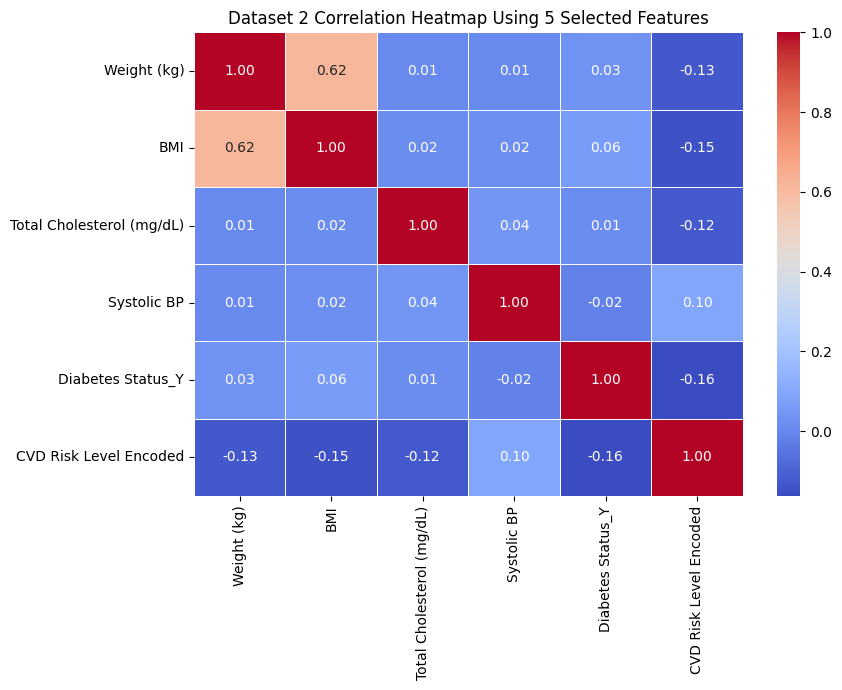

In [ ]:

heatmap2_df = X2.copy()
heatmap2_df["CVD Risk Level Encoded"] = y2

plt.figure(figsize=(9, 7))

corr2 = heatmap2_df.corr(numeric_only=True)

sns.heatmap(
    corr2,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Dataset 2 Correlation Heatmap Using 5 Selected Features")
plt.tight_layout()
plt.show()


## Cell 13: Define Dataset 2 Models

These are the same model types used for Dataset 1, but now they are trained only on the 5 selected Dataset 2 features.


In [ ]:
!pip install xgboost lightgbm catboost

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [ ]:
models2 = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, multi_class='auto', random_state=321))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel='rbf', probability=True, random_state=321))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Decision Tree": DecisionTreeClassifier(random_state=321, max_depth=5),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=321,
        max_depth=6
    ),

     "Gradient Boosting": GradientBoostingClassifier(
        random_state=321
    ),


}


## Cell 14: Dataset 2 Model Metrics Table Using Only 5 Features

This cell trains every Dataset 2 model using only the selected 5 features and prints the multiclass classification metrics.


In [ ]:

results2 = []

for name, model in models2.items():
    model.fit(X2_train, y2_train)

    y2_pred = model.predict(X2_test)

    if hasattr(model, "predict_proba"):
        y2_prob = model.predict_proba(X2_test)
        roc_auc = roc_auc_score(
            y2_test,
            y2_prob,
            multi_class="ovr",
            average="weighted"
        )
    else:
        roc_auc = np.nan

    results2.append({
        "Model": name,
        "Accuracy": accuracy_score(y2_test, y2_pred),
        "Precision Weighted": precision_score(y2_test, y2_pred, average="weighted", zero_division=0),
        "Recall Weighted": recall_score(y2_test, y2_pred, average="weighted", zero_division=0),
        "F1 Weighted": f1_score(y2_test, y2_pred, average="weighted", zero_division=0),
        "F1 Macro": f1_score(y2_test, y2_pred, average="macro", zero_division=0),
        "ROC-AUC": roc_auc
    })

results2_df = pd.DataFrame(results2).sort_values(by="ROC-AUC", ascending=False)
display(results2_df)

,Model,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro,ROC-AUC
4,Random Forest,0.552288,0.480471,0.552288,0.513620,0.395059,0.697839
0,Logistic Regression,0.581699,0.495600,0.581699,0.533447,0.410734,0.696488
1,SVM,0.578431,0.494693,0.578431,0.533227,0.412298,0.662919
5,Gradient Boosting,0.519608,0.483196,0.519608,0.492625,0.395659,0.653608
3,Decision Tree,0.575163,0.566753,0.575163,0.548433,0.456787,0.640930
2,KNN,0.500000,0.452132,0.500000,0.469464,0.369495,0.585494



## Cell 15: Dataset 2 Confusion Matrices and Classification Reports

This cell prints a confusion matrix and classification report for every Dataset 2 model using only the 5 selected features.


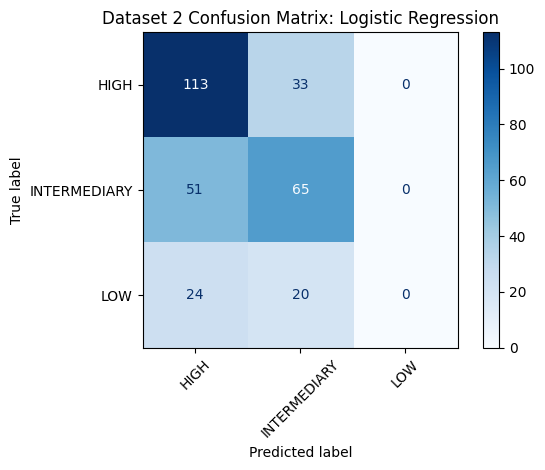


Logistic Regression
              precision    recall  f1-score   support

        HIGH       0.60      0.77      0.68       146
INTERMEDIARY       0.55      0.56      0.56       116
         LOW       0.00      0.00      0.00        44

    accuracy                           0.58       306
   macro avg       0.38      0.44      0.41       306
weighted avg       0.50      0.58      0.53       306



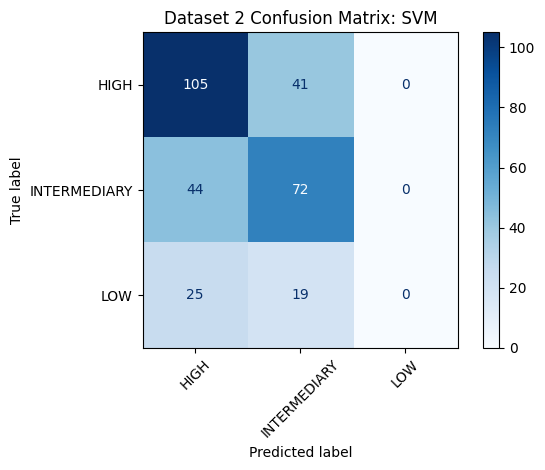


SVM
              precision    recall  f1-score   support

        HIGH       0.60      0.72      0.66       146
INTERMEDIARY       0.55      0.62      0.58       116
         LOW       0.00      0.00      0.00        44

    accuracy                           0.58       306
   macro avg       0.38      0.45      0.41       306
weighted avg       0.49      0.58      0.53       306



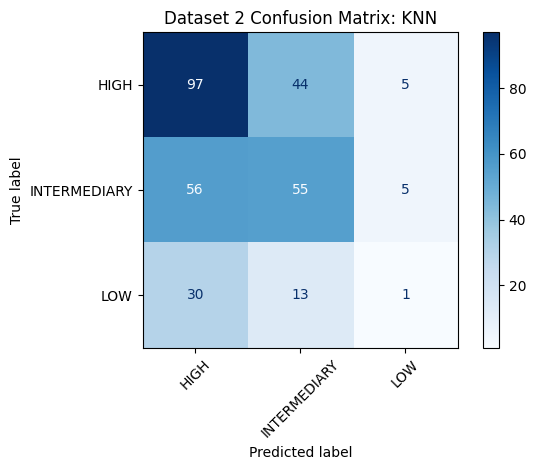


KNN
              precision    recall  f1-score   support

        HIGH       0.53      0.66      0.59       146
INTERMEDIARY       0.49      0.47      0.48       116
         LOW       0.09      0.02      0.04        44

    accuracy                           0.50       306
   macro avg       0.37      0.39      0.37       306
weighted avg       0.45      0.50      0.47       306



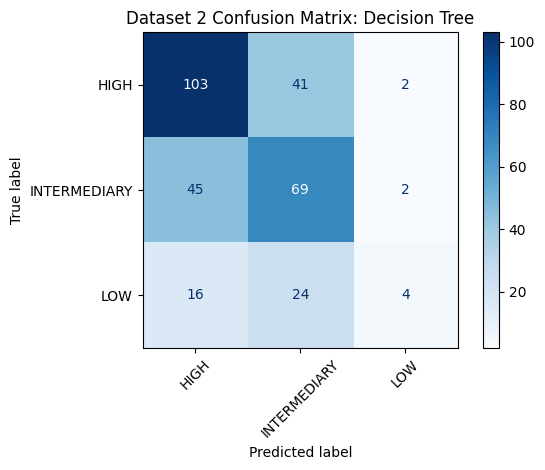


Decision Tree
              precision    recall  f1-score   support

        HIGH       0.63      0.71      0.66       146
INTERMEDIARY       0.51      0.59      0.55       116
         LOW       0.50      0.09      0.15        44

    accuracy                           0.58       306
   macro avg       0.55      0.46      0.46       306
weighted avg       0.57      0.58      0.55       306



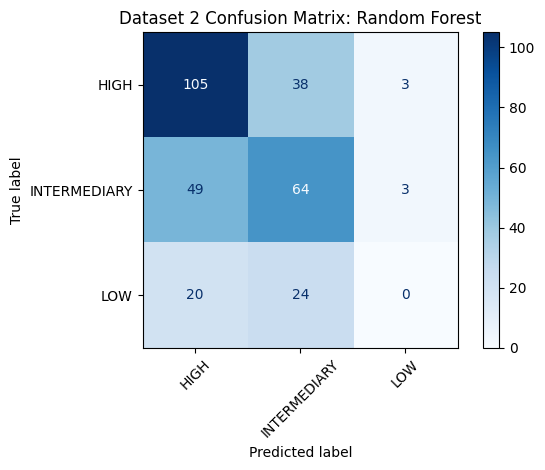


Random Forest
              precision    recall  f1-score   support

        HIGH       0.60      0.72      0.66       146
INTERMEDIARY       0.51      0.55      0.53       116
         LOW       0.00      0.00      0.00        44

    accuracy                           0.55       306
   macro avg       0.37      0.42      0.40       306
weighted avg       0.48      0.55      0.51       306



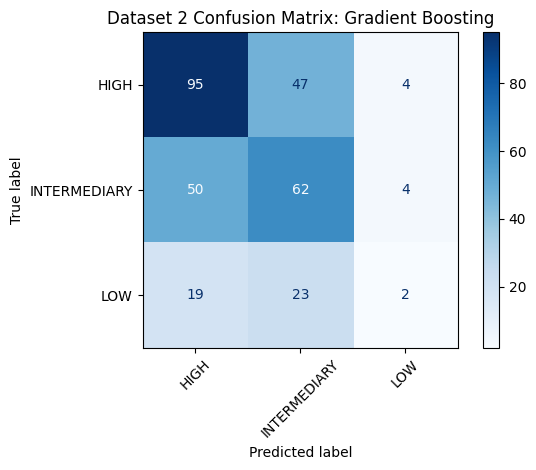


Gradient Boosting
              precision    recall  f1-score   support

        HIGH       0.58      0.65      0.61       146
INTERMEDIARY       0.47      0.53      0.50       116
         LOW       0.20      0.05      0.07        44

    accuracy                           0.52       306
   macro avg       0.42      0.41      0.40       306
weighted avg       0.48      0.52      0.49       306



In [ ]:

for name, model in models2.items():
    model.fit(X2_train, y2_train)

    y2_pred = model.predict(X2_test)

    cm = confusion_matrix(y2_test, y2_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=le2.classes_
    )

    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Dataset 2 Confusion Matrix: {name}")
    plt.tight_layout()
    plt.show()

    print(f"\n{name}")
    print(classification_report(
        y2_test,
        y2_pred,
        target_names=le2.classes_,
        zero_division=0
    ))


## Cell 16: Dataset 2 SHAP Summary Plot Using Only the 5 Selected Features


SHAP is calculated using the 5-feature Dataset 2 model.

Target classes: ['HIGH', 'INTERMEDIARY', 'LOW']


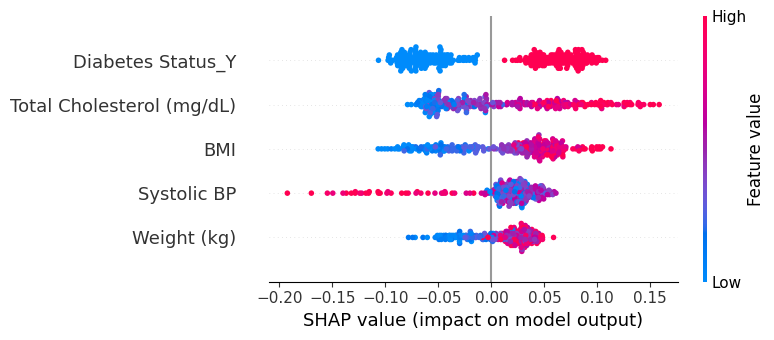

In [ ]:
# Dataset 2 SHAP Summary Plot for HIGH Risk Only

import shap

rf2_shap = RandomForestClassifier(
    n_estimators=200,
    random_state=321,
    max_depth=6,
    class_weight="balanced"
)

rf2_shap.fit(X2_train, y2_train)

explainer2 = shap.TreeExplainer(rf2_shap)
shap_values2 = explainer2.shap_values(X2_test)

print("Target classes:", list(le2.classes_))

high_index = list(le2.classes_).index("HIGH")

if isinstance(shap_values2, list):
    shap.summary_plot(
        shap_values2[high_index],
        X2_test,
        feature_names=X2_test.columns,
        show=True
    )
else:
    shap.summary_plot(
        shap_values2[:, :, high_index],
        X2_test,
        feature_names=X2_test.columns,
        show=True
    )

## Cell 17: Dataset 2 ROC Curves With Confidence Bands

This cell plots ROC curves for every Dataset 2 model with bootstrap confidence bands.


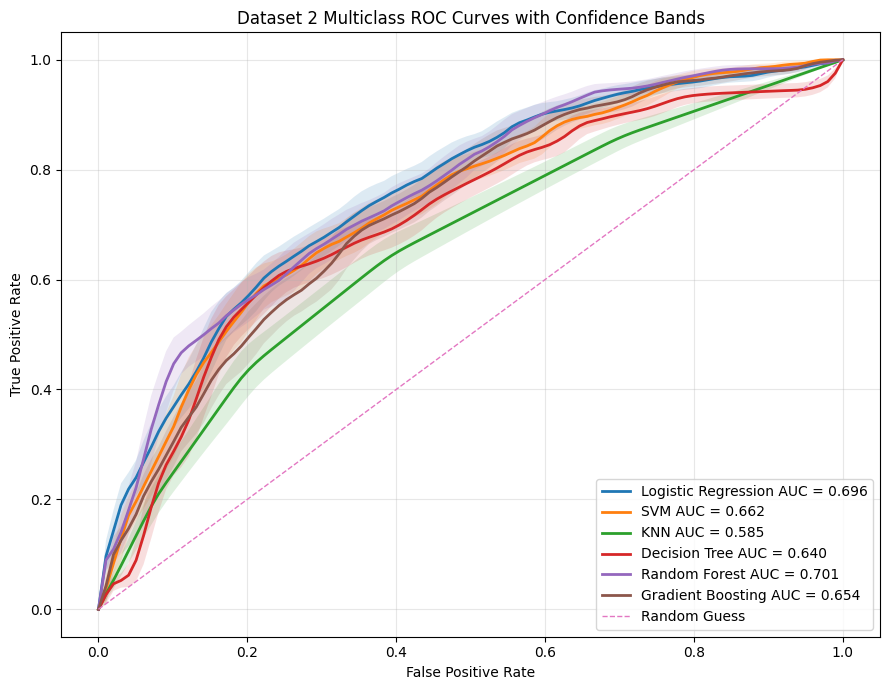

,Model,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro,ROC-AUC
4,Random Forest,0.552288,0.480471,0.552288,0.513620,0.395059,0.697839
0,Logistic Regression,0.581699,0.495600,0.581699,0.533447,0.410734,0.696488
1,SVM,0.578431,0.494693,0.578431,0.533227,0.412298,0.662919
5,Gradient Boosting,0.519608,0.483196,0.519608,0.492625,0.395659,0.653608
3,Decision Tree,0.575163,0.566753,0.575163,0.548433,0.456787,0.640930
2,KNN,0.500000,0.452132,0.500000,0.469464,0.369495,0.585494


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(9, 7))

n_bootstraps = 300
rng = np.random.RandomState(321)
mean_fpr = np.linspace(0, 1, 100)

classes2 = np.unique(y2_test)
y2_test_bin = label_binarize(y2_test, classes=classes2)

for name, model in models2.items():
    model.fit(X2_train, y2_train)

    if hasattr(model, "predict_proba"):
        y2_score = model.predict_proba(X2_test)
    else:
        print(f"Skipping {name}: no predict_proba available")
        continue

    y2_test_array = np.array(y2_test_bin)
    y2_score_array = np.array(y2_score)

    tprs = []
    aucs = []

    for i in range(n_bootstraps):
        indices = rng.randint(0, len(y2_score_array), len(y2_score_array))

        if len(np.unique(y2_test[indices])) < 2:
            continue

        try:
            roc_auc_boot = roc_auc_score(
                y2_test_array[indices],
                y2_score_array[indices],
                multi_class="ovr",
                average="weighted"
            )

            fpr_boot, tpr_boot, _ = roc_curve(
                y2_test_array[indices].ravel(),
                y2_score_array[indices].ravel()
            )

            aucs.append(roc_auc_boot)

            interp_tpr = np.interp(mean_fpr, fpr_boot, tpr_boot)
            interp_tpr[0] = 0.0
            tprs.append(interp_tpr)

        except ValueError:
            continue

    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)

    tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
    tpr_lower = np.maximum(mean_tpr - std_tpr, 0)

    plt.plot(
        mean_fpr,
        mean_tpr,
        linewidth=2,
        label=f"{name} AUC = {np.mean(aucs):.3f}"
    )

    plt.fill_between(
        mean_fpr,
        tpr_lower,
        tpr_upper,
        alpha=0.15
    )

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Dataset 2 Multiclass ROC Curves with Confidence Bands")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

results2_df = pd.DataFrame(results2).sort_values(by="ROC-AUC", ascending=False)
display(results2_df)